# 13_核方法-线性核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们来聊聊线性核\~

核方法中的「线性核」其实很简单，它就是两个向量之间的内积（点积）。

那么，什么是核方法？

在机器学习中，我们经常需要对数据进行转换，使得数据能够在一个更高维的空间中更好地表现出来（比如能被更容易地区分）。传统上，我们可能需要手动地设计一个“特征映射”函数，把原始数据从低维空间转换到高维空间。然而，这种手动映射往往既复杂又容易出错。

核方法（Kernel Methods）的妙处在于，它提供了一种“隐式地”在高维空间中计算数据相似度的方法，而不需要我们明确地知道转换后的坐标。也就是说，它通过一个**核函数**直接计算在高维空间中的内积，避免了昂贵的计算。

#### 线性核的定义

对于线性核，它的定义非常直观：

如果有两个向量 **x** 和 **y**，线性核 $K(x, y)$就等于这两个向量的点积，即：


$$
K(x, y) = x \cdot y = \sum_{i=1}^{n} x_i y_i
$$


这意味着，我们实际上并没有把数据投影到更高维的空间，而是直接在原始空间中计算它们的相似度。

#### 为什么称作“线性”核？

称它为“线性”核，是因为它反映了两个向量之间的线性关系。换句话说，使用线性核相当于在一个线性模型下比较数据，得出来的决策边界通常也是一条直线（在二维空间中）或一个超平面（在更高维空间中）。

#### 线性核的作用和优点

- **简单直观**：线性核很容易理解和实现。它直接利用输入特征的线性组合来测量相似度，没有复杂的数学变换。
- **计算效率高**：由于只是计算简单的内积，计算量相对其他复杂核（比如高斯核、多项式核）要小，速度较快。
- **适合线性可分问题**：当数据在原始空间中已经较好地线性可分时，使用线性核能得到非常不错的效果。例如，在使用支持向量机（SVM）进行分类时，若数据本身就呈现线性分布，那么选择线性核是一个自然的选择。

#### 线性核与非线性核的对比

- **线性核**：适用于数据本身呈线性关系的情况。如果数据在原始空间中就可以用直线或超平面划分，那么线性核能够很好地捕捉这种关系。
- **非线性核**：如果数据的分布较为复杂，无法用简单的直线或超平面分开时，就需要用到像高斯核（RBF核）、多项式核等。这些核函数可以将数据映射到更高维的空间，使得数据在新空间中可能变得线性可分。

当你在做一个考试，每个试题都是一个向量。如果你想比较两个试卷的相似度，你可以直接把每一题的得分相乘后相加，得到一个总分，这个总分越高，说明两份试卷越相似。线性核就是这么个简单的“对比方法”。它没有花哨的数学技巧，只是简单地直接对比原始数据。

## 原理详解

### 核函数的基本思想

假设有一个从原始输入空间到某个特征空间的映射函数  
$\varphi : \mathbb{R}^n \rightarrow \mathcal{F},$  
传统方法中，我们需要明确构造这个映射后在高维特征空间上进行计算。但核方法的关键在于，直接构造一个函数 $K(x, y)$满足  
$K(x, y) = \langle \varphi(x), \varphi(y) \rangle_{\mathcal{F}},$  
其中 $\langle \cdot, \cdot \rangle_{\mathcal{F}}$ 表示在特征空间 $\mathcal{F}$ 内的内积。

### 线性核的定义

对于线性核，我们直接选取映射为恒等映射，即  
$\varphi(x) = x.$  
所以，线性核函数变为  
$K(x, y) = \langle x, y \rangle = \sum_{i=1}^{n} x_i y_i.$  
这说明，线性核在特征空间上与原始空间保持一致，内积直接反映输入数据间的线性相关性。

### 相关的几何意义

在线性核下，由于内积直接反映向量间的角度和模长关系，我们可以得到以下几何直观：

- **相似性度量**：两个向量的内积越大，表示它们方向越接近（如果同时模长较大），即说明样本的特征表现较为相似。
- **决策超平面**：例如在线性支持向量机（SVM）中，决策函数通常写作  
$f(x) = \text{sign}\left(\langle w, x \rangle + b\right),$  
其中 $w$和 $b$即由训练数据学习得到的参数。这里 $\langle w, x \rangle$就是利用线性核的内积计算。

## 公式推导

对于二分类问题，给定训练数据 $\{(x_i, y_i)\}_{i=1}^{m}$，其中 $x_i \in \mathbb{R}^n$ 且 $y_i \in \{-1, +1\}$。SVM的目标是寻找一个超平面使得两个类别被最大化间隔分开。

原始形式可以写为：


$$
\min_{w, b} \quad \frac{1}{2} \|w\|^2 \quad \text{满足} \quad y_i (\langle w, x_i \rangle + b) \geq 1, \quad \forall \ i.
$$


### 对偶问题的构造

引入拉格朗日乘子 $\alpha_i \geq 0$（每个数据点对应一个乘子），构造拉格朗日函数：


$$
L(w,b,\alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^{m} \alpha_i \left[y_i (\langle w, x_i \rangle + b) - 1\right].
$$


对 $w$ 和 $b$ 求偏导，并令其为零，得到最优条件：

- 关于 $w$：  
$\frac{\partial L}{\partial w} = w - \sum_{i=1}^{m} \alpha_i y_i x_i = 0 \quad \Rightarrow \quad w = \sum_{i=1}^{m} \alpha_i y_i x_i.$
- 关于 $b$：  
$\frac{\partial L}{\partial b} = - \sum_{i=1}^{m} \alpha_i y_i = 0 \quad \Rightarrow \quad \sum_{i=1}^{m} \alpha_i y_i = 0.$

将 $w$ 的表达式代入拉格朗日函数，消去 $w$ 后，得到对偶问题：

$\max_{\alpha} \quad \sum_{i=1}^{m} \alpha_i - \frac{1}{2}\sum_{i=1}^{m} \sum_{j=1}^{m} \alpha_i \alpha_j y_i y_j \langle x_i, x_j \rangle,$  
$\text{满足} \quad \alpha_i \geq 0, \quad \sum_{i=1}^{m} \alpha_i y_i = 0.$

### 核函数在对偶问题中的应用

在线性核的情形下，由于 $\varphi(x) = x$，核函数  
$K(x_i, x_j) = \langle \varphi(x_i), \varphi(x_j) \rangle = \langle x_i, x_j \rangle.$  
所以对偶问题变成：

$\max_{\alpha} \quad \sum_{i=1}^{m} \alpha_i - \frac{1}{2}\sum_{i,j=1}^{m} \alpha_i \alpha_j y_i y_j K(x_i, x_j),$  
$\text{满足} \quad \alpha_i \geq 0, \quad \sum_{i=1}^{m} \alpha_i y_i = 0.$

这一步说明：如果我们使用核函数，将原始数据投影到高维空间中进行计算，那么核函数在对偶问题中承担的正是计算投影后内积的作用；而在线性核中，直接就是计算原始向量的内积。

### 决策函数

求解对偶问题之后得到最优拉格朗日乘子 $\alpha_i^*$ 后，根据 KKT 条件，可重构权向量


$$
w = \sum_{i=1}^{m} \alpha_i^* y_i x_i.
$$


决策函数为


$$
f(x) = \text{sign}\left(\langle w, x \rangle + b \right) = \text{sign}\left(\sum_{i=1}^{m} \alpha_i^* y_i \langle x_i, x \rangle + b\right).
$$


这其中核函数 $K(x_i, x) = \langle x_i, x \rangle$ 自然出现。

对于非线性核，决策函数则写为


$$
f(x) = \text{sign}\left(\sum_{i=1}^{m} \alpha_i^* y_i K(x_i, x) + b\right),
$$


但线性核中 $K$ 的计算不涉及隐式映射，直接操作原始向量即可。

## 算法流程

#### 数据预处理

1. **数据收集**：收集训练样本 $\{(x_i, y_i)\}_{i=1}^{m}$。
2. **特征归一化**：为提高数值稳定性和收敛速度，通常会对数据进行归一化或标准化。

#### 构造核矩阵

1. **计算Gram矩阵**：
2. 对于所有训练样本，构造一个 $m \times m$ 的核矩阵 $K$，其中每个元素  
$K_{ij} = K(x_i, x_j) = \langle x_i, x_j \rangle.$  
对于线性核来说，就是直接计算内积。

#### 求解对偶问题

1. **构造对偶优化问题**：
2. 利用前面推导得到的对偶形式，即  
$\max_{\alpha} \quad \sum_{i=1}^{m} \alpha_i - \frac{1}{2}\sum_{i,j=1}^{m} \alpha_i \alpha_j y_i y_j K_{ij},$  
同时满足约束条件：$\alpha_i \geq 0$ 和 $\sum_{i=1}^{m} \alpha_i y_i = 0$。
3. **求解方法**：
4. 通常会采用二次规划（Quadratic Programming, QP）的方式，或利用SMO（Sequential Minimal Optimization）算法来迭代求解最优的 $\alpha_i$ 值。

#### 模型构建

1. **重构权向量**：
2. 根据最优拉格朗日乘子，构造权向量  
$w = \sum_{i=1}^{m} \alpha_i^* y_i x_i.$
3. **确定偏置** $b$：
4. 从满足KKT条件且为支持向量的样本中计算 $b$，例如对任一支持向量 $x_k$，有  
$y_k (\langle w, x_k \rangle + b) = 1 \quad \Rightarrow \quad b = y_k - \langle w, x_k \rangle.$  
一般可对多个支持向量求平均以提高稳定性。

#### 分类决策

1. **计算决策函数**：
2. 对任一新样本 $x$，决策函数为  
$f(x) = \text{sign}\left(\langle w, x \rangle + b\right) = \text{sign}\left(\sum_{i=1}^{m} \alpha_i^* y_i \langle x_i, x \rangle + b\right).$
3. **完成分类**：
4. 若 $f(x) \geq 0$，则分类为正类；否则，分类为负类。

#### 流程总结

1. **数据预处理**：标准化样本数据。
2. **构造核矩阵**：利用线性核计算所有样本间内积。
3. **求解对偶问题**：利用二次规划或SMO方法获得最优 $\alpha$。
4. **重构模型**：计算权向量 $w$ 及偏置 $b$。
5. **分类决策**：利用决策函数对新样本进行分类。

## 完整案例

我们采用 Python 构造一个二分类问题的合成数据集，并利用支持向量机（SVM）进行分类。

为了展示核方法中线性核的应用，我们将使用线性核来构建 SVM 分类器。

具体步骤包括：

1. **数据生成与预处理**：利用 `sklearn.datasets.make_blobs` 生成具有一定重叠度的二维数据，方便可视化。数据集的两个类别在原始空间线性可分但存在噪音。
2. **模型构建与训练**：采用支持向量机（SVM）分类器，核函数选用线性核。给出原始 SVM 的构造过程，并利用数据进行拟合。
3. **交叉验证与参数优化**：利用网格搜索（GridSearchCV）对模型进行超参数调优。虽然线性核只有一个重要参数 C，但这里也展示参数调节的过程。介绍如何利用交叉验证（CV）来找到最优的正则化参数。
4. **模型评估和可视化**：绘制决策边界和支持向量，以便直观比较不同数据点的分类情况，绘制混淆矩阵，展示模型在测试集上的分类效果，通过 ROC 曲线显示分类器性能。

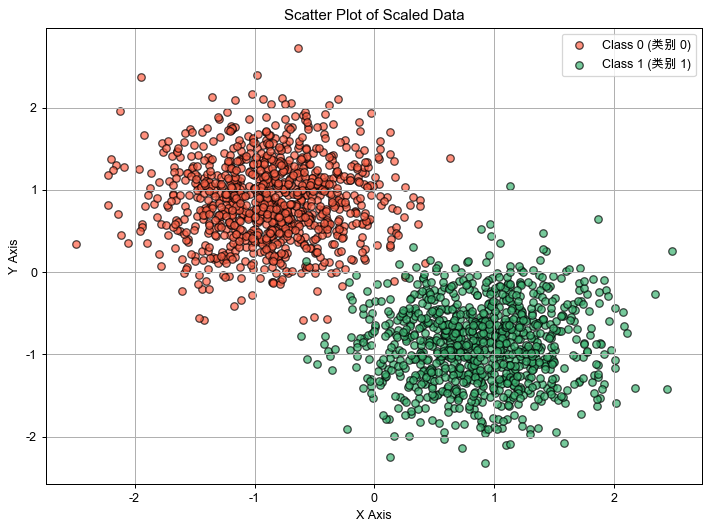

Classification Report (使用原始参数 C=1.0):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       300
           1       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

Fitting 5 folds for each of 13 candidates, totalling 65 fits


最佳参数： {'C': np.float64(0.001)}
最佳交叉验证得分： 0.9971428571428571
Classification Report (使用优化后的参数):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       300
           1       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



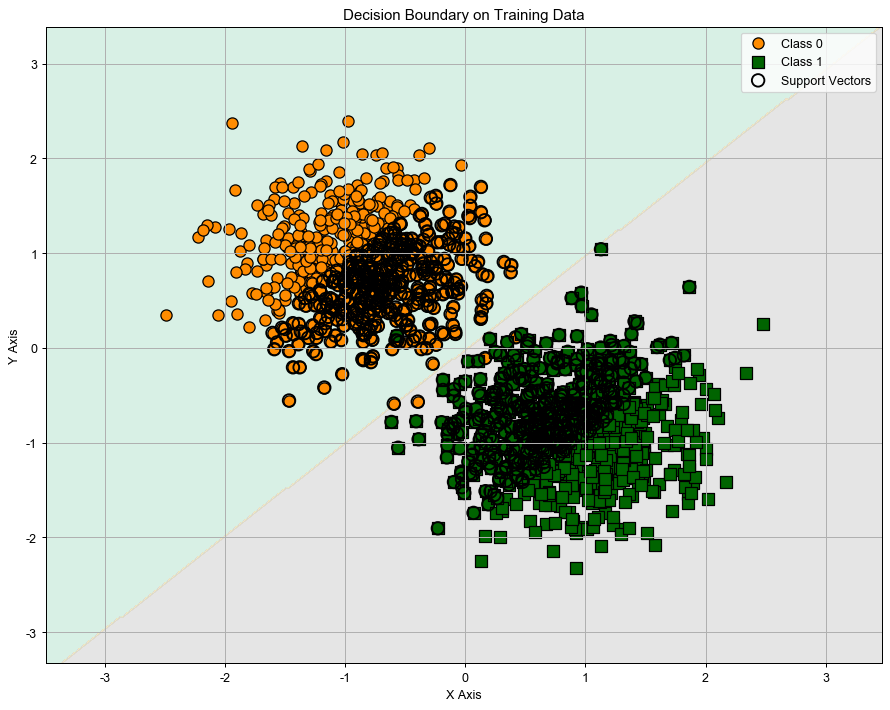

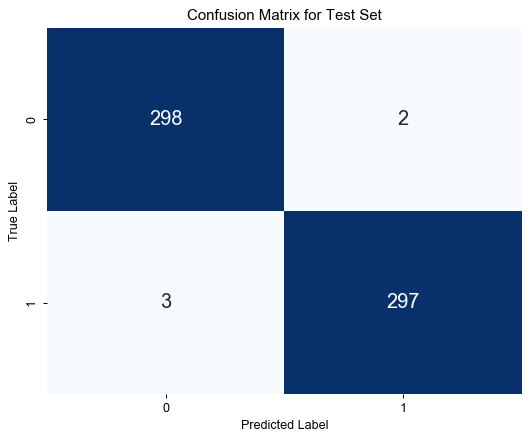

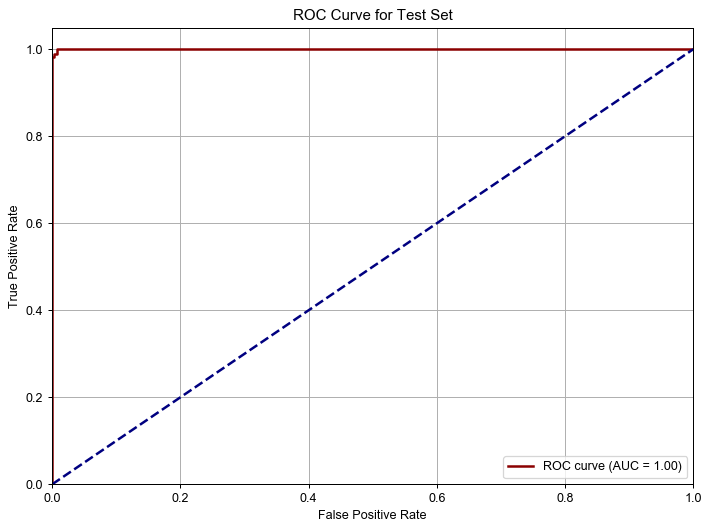

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm, datasets, metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

np.random.seed(42)

# 1. 数据生成和预处理
# 使用 make_blobs 生成二维数据，方便可视化。设定 2 个簇，每个簇 2000 个点，簇间一定重叠，便于展示支持向量机分类效果。
X, y = make_blobs(n_samples=2000, centers=2, n_features=2, cluster_std=2.0, random_state=42)

# 数据标准化对于 SVM 训练收敛速度和数值稳定性非常重要
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集，比例 70% : 30%
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 可视化原始数据分布
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], color='tomato', alpha=0.7, edgecolors='k',
            label='Class 0 (类别 0)')
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], color='mediumseagreen', alpha=0.7, edgecolors='k',
            label='Class 1 (类别 1)')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Scatter Plot of Scaled Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

"""
【数据生成说明】
数据集使用 make_blobs 生成，构造两个簇。标准化操作确保每个特征均值为 0，方差为 1，有利于 SVM 求解最优边界。散点图中两种颜色区分不同类别
"""

# 2. SVM 模型构建与训练（使用线性核）

# 采用 SVM 的线性核（kernel='linear'），C 参数控制正则化力度。
svm_linear = svm.SVC(kernel='linear', C=1.0, probability=True, random_state=42)

# 训练模型
svm_linear.fit(X_train, y_train)

# 预测测试集
y_pred = svm_linear.predict(X_test)
y_score = svm_linear.decision_function(X_test)

# 输出分类报告与准确率
print("Classification Report (使用原始参数 C=1.0):")
print(classification_report(y_test, y_pred))

# 3. 参数优化（交叉验证和网格搜索）

# 利用网格搜索优化 SVM 模型的参数 C
param_grid = {'C': np.logspace(-3, 3, 13)}  # 从 1e-3 到 1e3 共 13 个取值
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(svm.SVC(kernel='linear', probability=True, random_state=42),
                           param_grid, cv=cv, scoring='accuracy', n_jobs=1, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

print("最佳参数：", grid_search.best_params_)
print("最佳交叉验证得分：", grid_search.best_score_)

# 使用优化后的参数构建最终模型
svm_linear_opt = grid_search.best_estimator_
y_pred_opt = svm_linear_opt.predict(X_test)
print("Classification Report (使用优化后的参数):")
print(classification_report(y_test, y_pred_opt))


# 4. 模型评估与可视化
# 可视化决策边界
def plot_decision_boundary(clf, X, y, title_str="Decision Boundary", resolution=0.02):
    """
    画出 SVM 分类器的决策边界以及支持向量
    参数：
        clf：训练好的分类器
        X：输入特征（二维）
        y：类别标签
        title_str: 图像标题
        resolution: 网格分辨率
    """
    # 设置网格范围
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # 预测网格点上的类别值
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 绘制决策区域
    plt.figure(figsize=(10, 8))
    cmap_light = plt.cm.Pastel2
    cmap_bold = plt.cm.Set1 
    plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_light)

    # 绘制训练数据点
    markers = ['o', 's']
    colors = ['darkorange', 'darkgreen']
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(X[y == cl, 0], X[y == cl, 1],
                    c=colors[idx], marker=markers[idx],
                    edgecolor='k', s=80, label=f'Class {cl}')

    # 绘制支持向量（仅对于 SVC 可用）
    if hasattr(clf, "support_vectors_"):
        plt.scatter(clf.support_vectors_[:, 0],
                    clf.support_vectors_[:, 1],
                    s=100, facecolors='none', edgecolors='k', linewidths=1.5,
                    label='Support Vectors')

    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')
    plt.title(title_str)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 使用优化后的 SVM 模型绘制决策边界（基于训练数据）
plot_decision_boundary(svm_linear_opt, X_train, y_train, title_str="Decision Boundary on Training Data")


# 绘制混淆矩阵
def plot_confusion_mat(true_labels, pred_labels, title_str="Confusion Matrix"):
    """
    绘制混淆矩阵，并以热力图方式展示每个类别的分类效果
    参数：
        true_labels: 真正的标签
        pred_labels: 预测的标签
        title_str: 图像标题
    """
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                annot_kws={"size": 16})
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title_str)
    plt.tight_layout()
    plt.show()


# 绘制测试集的混淆矩阵
plot_confusion_mat(y_test, y_pred_opt, title_str="Confusion Matrix for Test Set")


# ROC 曲线与 AUC 指标
def plot_roc_curve(true_labels, y_scores, title_str="ROC Curve"):
    """
    绘制 ROC 曲线及计算 AUC 指标，反映模型分类性能
    参数：
        true_labels: 真正的标签（0/1）
        y_scores: 分类决策函数或预测概率分数
        title_str: 图像标题
    """
    # 计算 FPR, TPR, threshold 和 AUC
    fpr, tpr, thresholds = roc_curve(true_labels, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkred', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title_str)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 由于 SVC 使用 probability=True，我们可以同时利用 decision_function 得到评分，这里对测试集应用 ROC 曲线绘制
plot_roc_curve(y_test, y_score, title_str="ROC Curve for Test Set")

代码中，我们使用 `make_blobs` 构造一个二维数据集，生成 2000 个样本，分成 2 个类别。数据分布较为自然，同时设置一定标准差（cluster_std=2.0），使得各类别存在一定重叠，模拟实际数据情况。

之后，利用 `StandardScaler` 对数据做标准化处理（均值为0、方差为1），这是非常关键的一步，因为 SVM 的内积计算依赖于各特征量纲一致。同时提高模型收敛速度和数值稳定性。

### SVM 模型构建与训练（线性核）

使用 `svm.SVC` 构造 SVM 分类器，kernel 参数置为 `'linear'`，正则化参数 C 初步设为 1.0。概率参数 `probability=True` 使得后续能够计算 ROC 曲线。

线性核下，模型的决策边界是一个直线（二维情况），由支持向量确定，其数学形式为 f(x)=sign(〈w, x〉+b)。模型在训练过程中自动求得支持向量及对应的权重参数。

通过 `classification_report` 输出模型在测试集上的各项指标（如精度、召回率、F1值），为后续模型调参和优化提供初步参考。

### 参数优化与交叉验证

**参数 C 的调节**，参数 C 控制 SVM 正则化力度，影响模型复杂度。采用 `np.logspace(-3, 3, 13)` 在 1e-3 到 1e3 范围内取 13 个值，通过网格搜索逐一验证，从而找到最优参数。

**交叉验证**，采用 5 折 StratifiedKFold 方法，保证每一折数据类别分布一致，提高调参结果的可靠性。

**最优参数及得分**，网格搜索完成后，打印最优参数及对应的交叉验证得分，并利用最佳模型构建最终 SVM 分类器。

通过调参获得最优参数，有助于防止过拟合，提高泛化能力，同时使模型在测试集上的分类效果更好。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

- **决策边界**：通过构建二维平面上的网格数据，调用训练好的 SVM 模型对每个网格点预测类别，绘制颜色区域。使用 contourf 绘制背景颜色，并用散点图标注训练数据与支持向量。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

- **混淆矩阵**：利用 sklearn 内置的 `confusion_matrix` 和 seaborn 的 heatmap 绘制混淆矩阵，颜色采用蓝色调（Blues）以便明显区分正确分类和误分类情况。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

- **ROC 曲线**：通过 `roc_curve` 和 `auc` 函数计算 ROC 曲线及 AUC 值，反映模型在不同阈值下的性能，AUC 值接近 1 时表示性能优越。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

## 模型分析

### 线性核优缺点

**优点：**

- **实现简单、直观易懂**：线性核仅仅是计算向量之间的内积，无需进行复杂的数据转换或隐式映射，因此数学公式和几何意义都非常直观。这使得它在理论分析和实现时都非常简单，便于学习和调试。
- **计算效率高**：由于直接在原始空间计算内积，运算复杂度通常为 $O(n)$（其中 $n$ 为特征数），对于大规模数据或高维数据（当数据本身呈现线性分布时）都具备较好的计算性能。相比那些需要隐式映射到高维空间的非线性核，线性核的计算负担较小。
- **泛化能力好**：在数据本身近似线性可分的情况下，线性核能够获得较好的分类效果。同时，通过正则化参数 $C$ 控制模型复杂度，避免过拟合，且参数的可调性较为简单。
- **模型解释性强**：在线性核下得到的模型权重 $\mathbf{w}$ 可以直接反映各个特征对于分类决策的重要性，这对一些需要解释模型决策依据的任务非常有帮助。

**缺点：**

- **适用范围受限**：线性核只能捕捉数据之间的线性关系。如果数据存在非线性关系或复杂交互作用，线性核可能导致模型欠拟合，进而无法有效区分不同类别。
- **无法自动引入非线性特征**：相比于如高斯核或多项式核这种内置非线性映射的核函数，线性核无法通过隐式映射自动构建高维特征空间，因此在处理高度非线性的数据时效果较差。
- **对数据噪音和异常值较敏感**：由于线性模型受到数据线性关系的直接影响，如果样本中存在异常点或噪声较大，会影响内积计算及最终边界的确定，导致模型鲁棒性下降。

### 与相似算法的对比

将线性核与其他几种常见的分类算法进行对比，内容涵盖优缺点及适用场景。

| **Algorithm** | **Advantages (优点)** | **Disadvantages (缺点)** | **Suitable Scenarios (适用场景)** |
|-|-|-|-|
| **Linear Kernel SVM** | 实现简单、计算高效；在线性可分数据上表现优异；模型解释性强，权重直接反映特征重要性 | 仅能解决线性问题；对噪声及异常值较敏感；当数据非线性时容易欠拟合 | 当数据在特征空间中近似线性可分，且要求模型易解释、计算速度快时 |
| **Logistic Regression** | 模型简单、训练速度快；输出概率解释性强；容易实现正则化防止过拟合 | 同样受限于线性关系；在特征交互较复杂的数据中可能表现欠佳；对异常值敏感 | 在线性关系比较明显、需要概率解释以及应用场景要求较低计算资源的场景 |
| **Non-linear Kernel SVM** | 通过内置核函数（如 RBF、高斯核）可捕捉非线性关系，适用于复杂数据；提供灵活度；能够自动构造高维特征空间 | 计算复杂度较高；参数调优较复杂（核参数、正则化参数需要同时搜索）；容易因参数设置不当而导致过拟合或欠拟合 | 当数据存在明显的非线性关系，且允许较长的训练时间，并且希望充分捕捉数据复杂结构时 |
| **Decision Trees / RF** | 模型直观、可以自动捕捉特征非线性关系和交互作用；不需要数据标准化；决策树结构易于解释；随机森林还可以降低过拟合风险 | 决策树单一模型容易过拟合；随机森林模型训练和推理较耗时；结果解释性虽然较好，但整体模型不如线性模型那样直接展示每个特征的重要性 | 当数据特征之间存在复杂的非线性关系和交互作用时，或者数据预处理有限且需要模型具有一定的解释能力时 |
| **Neural Networks** | 强大的非线性建模能力，可以处理高维复杂数据；适用于大规模数据集；灵活度高，能够自动学习特征 | 模型训练时间较长，参数众多且缺乏直观解释；需要大量数据才能达到较好的性能；超参数调优较复杂 | 当数据规模大、特征间存在高度非线性关系且容忍较长训练时间；且不要求模型有强解释性时 |

### 选择论述

在选择采用 线性核 SVM 时，应考虑以下几点：

**优选情况：**

- **数据近似线性可分时：** 如果数据在经过标准化后，在原始特征空间中就能基本用一条直线或超平面分开，那么线性核是非常合适的选择，它具有高效、简单、解释性强的优势。
- **计算资源有限或需求实时应用：** 由于线性核的计算复杂度低，适合于需要快速预测和实时响应的场景，例如在一些在线预测系统中。
- **模型解释性要求较高：** 当业务领域要求能够解释模型决策依据时，线性核模型提供的权重向量可以直观地展示特征的重要性，便于理解和部署。

**考虑其他算法的情况：**

- **数据存在复杂非线性关系：** 如果初步探索发现数据分布明显非线性（例如存在弧形、环形或交叉的分类边界），则建议选择如非线性核 SVM（例如 RBF 核 SVM）、神经网络或决策树等能够自动捕捉非线性特征的算法。
- **数据噪音和异常值较多：** 在这种情况下，线性模型可能受噪音影响较大，决策树类方法或随机森林等集成算法通常能更好地处理噪音数据，并提高鲁棒性。
- **特征间存在复杂交互作用：** 当数据特征之间的关系不仅仅是线性的，而是存在深层次交互作用时，神经网络和集成决策树往往能够发现这些更复杂的模式，提升预测准确率。

总结来说，**核方法-线性核 SVM** 是一种经典而高效的算法，适用于数据线性可分、计算资源有限以及需要解释性较强的应用场景；而对于那些存在明显非线性关系、噪声较多或者特征交互复杂的情况，非线性方法（如 RBF 核 SVM、神经网络、集成决策树）则更具优势。根据数据的实际情况和项目需求，选择最合适的算法能够在保证高准确度的同时兼顾模型的可解释性和计算效率。